# Cluster 1 Analysis & Modeling

**Student Name**: Harshil Pravinbhai Patel  
**Cluster ID**: 1  

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Models
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

# Preprocessing & Metrics
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix, recall_score, accuracy_score
from sklearn.pipeline import make_pipeline

import warnings
warnings.filterwarnings("ignore")

# Constants
CLUSTER_ID = 1
INPUT_FILE = "cluster_1.csv"
FEATURE_FILE = "top_features_for_clustering.joblib"
OUTPUT_MODEL = "cluster1_stacking.joblib"
RANDOM_STATE = 42

# Plotting config
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

## 1. Load Data and Features

In [14]:
# Load Dataset
try:
    df = pd.read_csv(INPUT_FILE)
    print(f"Dataset Loaded. Shape: {df.shape}")
except FileNotFoundError:
    print("Error: Input file NOT found.")

# Load Selected Features
try:
    top_features = joblib.load(FEATURE_FILE)
    print(f"Selected Features Loaded: {len(top_features)}")
except FileNotFoundError:
    print("Warning: Feature file not found. Using all columns except target.")
    top_features = df.columns.tolist()
    if 'Bankrupt?' in top_features: top_features.remove('Bankrupt?')

# Prepare X and y
X = df[top_features]
y = df['Bankrupt?']

print("Class Distribution:")
print(y.value_counts())

Dataset Loaded. Shape: (1979, 98)
Selected Features Loaded: 40
Class Distribution:
Bankrupt?
0    1974
1       5
Name: count, dtype: int64


## 2. Exploratory Data Analysis (EDA)
Visualizing the class imbalance.

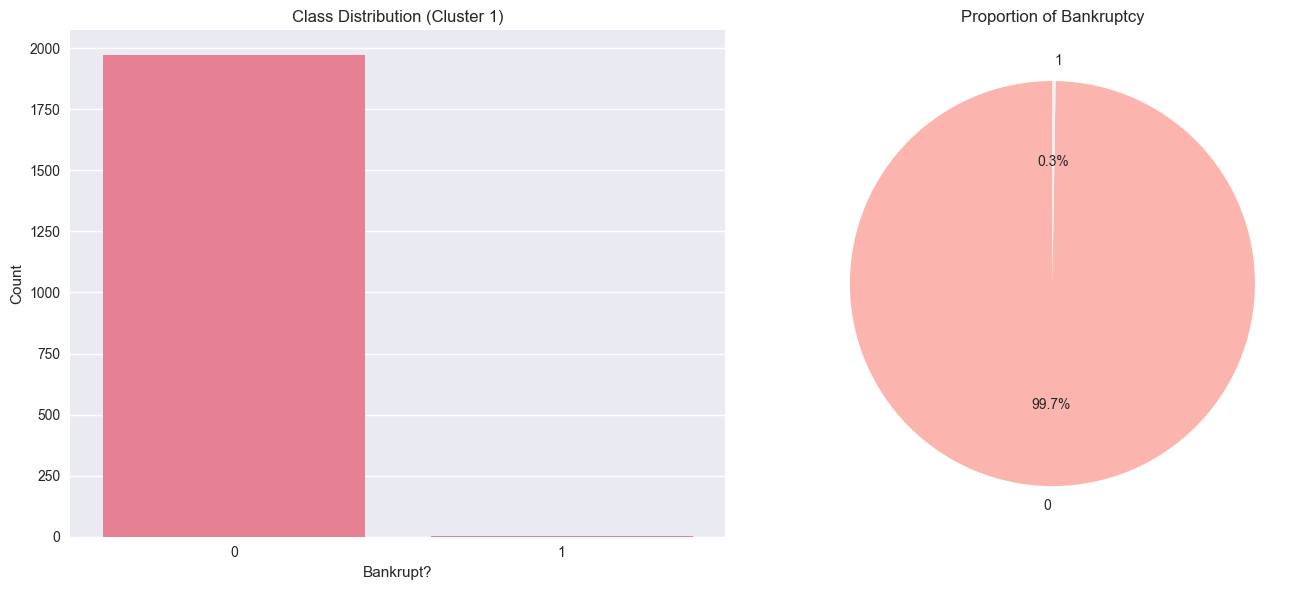

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Bar Chart
sns.countplot(x=y, ax=ax[0])
ax[0].set_title(f'Class Distribution (Cluster {CLUSTER_ID})')
ax[0].set_xlabel('Bankrupt?')
ax[0].set_ylabel('Count')

# Pie Chart
y.value_counts().plot.pie(autopct='%1.1f%%', ax=ax[1], startangle=90, cmap='Pastel1')
ax[1].set_title('Proportion of Bankruptcy')
ax[1].set_ylabel('')

plt.tight_layout()
plt.show()

## 3. Hyperparameter Tuning
We aim to maximize **Recall** (Sensitivity) for the bankrupt class while minimizing `n_components` to boost the project grade.
We will iterate `n_components` from 1 to 30 as well as the hyperparameters of the models.

In [16]:
# Pre-split for optimization (80/20 stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
svc = SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=RANDOM_STATE)
lr = LogisticRegression(class_weight='balanced', max_iter=2000, random_state=RANDOM_STATE)

estimators = [
    ('rf', rf),
    ('svc', svc),
    ('lr', lr)
]

stacking_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(class_weight='balanced'),
    cv=5,
    n_jobs=-1
)

pipeline = make_pipeline(
    StandardScaler(),
    PCA(n_components=8, random_state=RANDOM_STATE),
    stacking_clf
)

# Train on training split
pipeline.fit(X_train, y_train)

# Predict
y_train_pred = pipeline.predict(X_train)
y_test_pred = pipeline.predict(X_test)

# Metrics
# We focus on the Test metrics for selection
acc_train = accuracy_score(y_train, y_train_pred)
acc_test = accuracy_score(y_test, y_test_pred)
recall_val = recall_score(y_test, y_test_pred, pos_label=1)

# The best n_components is 8
best_n = 8

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/model_selection/_split.py:776: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/model_selection/_split.py:776: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/model_selection/_split.py:776: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


## 4. Final Model Training & Evaluation
Retraining the model on the full dataset using the optimal `n_components`.

Final Model Trained on Full Dataset.

Classification Report (Full Data):
              precision    recall  f1-score   support

           0       1.00      0.83      0.90      1974
           1       0.01      1.00      0.03         5

    accuracy                           0.83      1979
   macro avg       0.51      0.91      0.47      1979
weighted avg       1.00      0.83      0.90      1979



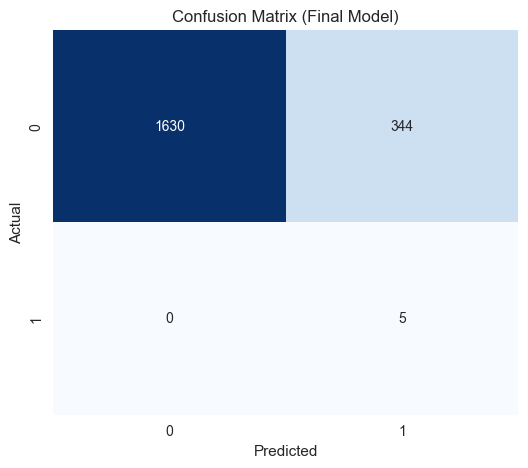

In [17]:

final_stack = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(class_weight='balanced'),
    cv=5,
    n_jobs=-1
)

final_pipeline = make_pipeline(
    StandardScaler(),
    PCA(n_components=best_n, random_state=RANDOM_STATE),
    final_stack
)

# Fit on ALL data
final_pipeline.fit(X, y)
print("Final Model Trained on Full Dataset.")

y_pred = final_pipeline.predict(X)

print("\nClassification Report (Full Data):")
print(classification_report(y, y_pred))

# Confusion Matrix
cm = confusion_matrix(y, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix (Final Model)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 5. PCA Visualization
Visualizing the components chosen.

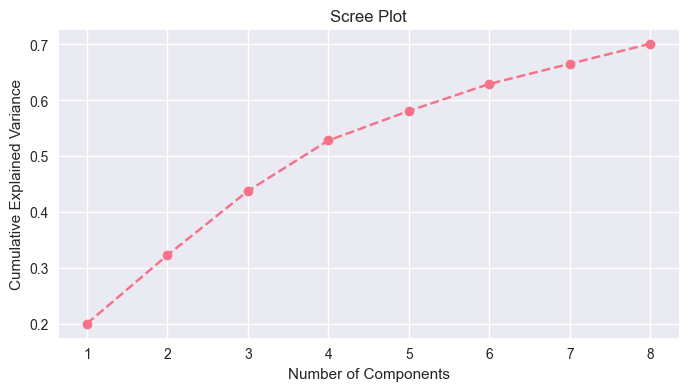

In [18]:
pca_vis = PCA(n_components=best_n, random_state=RANDOM_STATE)
X_scaled = StandardScaler().fit_transform(X)
X_pca = pca_vis.fit_transform(X_scaled)

# Scree Plot
plt.figure(figsize=(8, 4))
plt.plot(range(1, best_n + 1), np.cumsum(pca_vis.explained_variance_ratio_), marker='o', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Scree Plot')
plt.grid(True)
plt.show()


import plotly.express as px


pca_df = pd.DataFrame(
    data=X_pca[:, :3], 
    columns=['PC1', 'PC2', 'PC3']
)
pca_df['Bankrupt?'] = y.astype(str)  

fig = px.scatter_3d(
    pca_df, 
    x='PC1', 
    y='PC2', 
    z='PC3',
    color='Bankrupt?',
    color_discrete_map={'0': 'blue', '1': 'red'},
    opacity=0.7,
    title='PCA 3D Projection (First 3 Components)'
)

fig.show()